# Where does the money go? 

Meet our little SaaS company. It sells three plans (Basic, Pro, Enterprise), bills through Stripe, and after twelve months
of business the leadership team has questions:

- How much recurring revenue do we have, and is it growing or leaking?
- Who leaves us, and why?
- Which plan actually pays the bills?
- How much money disappears because someone's credit card said "no"?

The pipeline (`sync` → `load` → `dbt build`) already did the heavy lifting and left tidy tables in `data/warehouse.duckdb`.
This notebook just asks them nicely. All amounts in USD, the story runs from August 2025 to July 2026.

In [9]:
import duckdb
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)


def query(sql: str) -> pd.DataFrame:
    """Run SQL against the warehouse and return the result as a DataFrame."""
    return con.sql(sql).df()

## 1. MRR: the number everyone stares at

MRR (Monthly Recurring Revenue) is what all active subscriptions would pay us in one month.
Yearly plans are spread over twelve months so they don't look like a jackpot in January and nothing after.

`mrr_monthly` is our waterfall: how much MRR we ended each month with, and which way it moved —
new customers coming in, upgrades and downgrades, and churn walking out the door.

In [10]:
mrr = query("select * from marts.mrr_monthly")
mrr

,month,mrr,active_customers,new_mrr,expansion_mrr,reactivation_mrr,contraction_mrr,churn_mrr,new_customers,churned_customers
0,2025-08-01,429.15,15,429.15,0.0,0.0,0.0,0.00,15,0
1,2025-09-01,1112.80,34,751.65,0.0,0.0,0.0,-68.00,21,2
2,2025-10-01,1596.95,49,533.15,0.0,0.0,0.0,-49.00,16,1
3,2025-11-01,2122.61,57,525.66,0.0,0.0,0.0,0.00,8,0
4,2025-12-01,3024.43,76,892.65,50.0,0.0,0.0,-40.83,20,1
5,2026-01-01,3693.75,91,749.98,50.0,0.0,0.0,-130.66,18,3
6,2026-02-01,3981.91,100,402.99,0.0,0.0,0.0,-114.83,11,2
7,2026-03-01,4867.06,116,812.15,130.0,0.0,0.0,-57.00,19,3
8,2026-04-01,5456.70,131,745.64,30.0,0.0,0.0,-186.00,19,4
9,2026-05-01,5966.02,144,601.15,140.0,0.0,0.0,-231.83,18,5


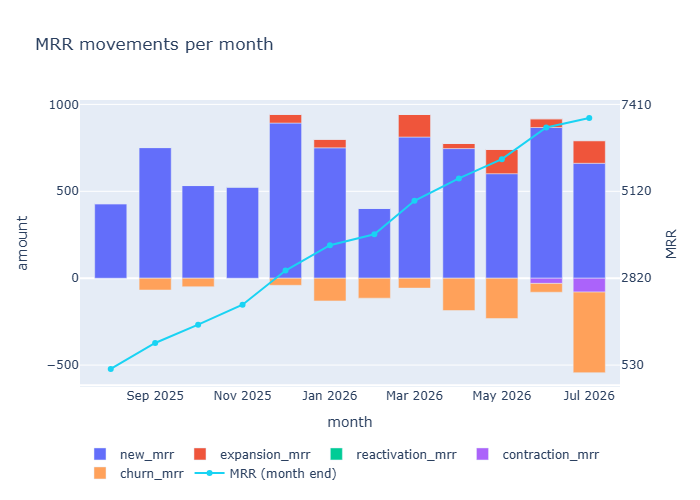

In [11]:
movements = mrr.melt(
    id_vars="month",
    value_vars=["new_mrr", "expansion_mrr", "reactivation_mrr", "contraction_mrr", "churn_mrr"],
    var_name="movement",
    value_name="amount",
)

fig = px.bar(movements, x="month", y="amount", color="movement", title="MRR movements per month")
fig.add_scatter(x=mrr.month, y=mrr.mrr, name="MRR (month end)", mode="lines+markers", yaxis="y2")
fig.update_layout(
    yaxis2=dict(overlaying="y", side="right", title="MRR", showgrid=False),
    legend=dict(orientation="h", yanchor="bottom", y=-0.35, title=None),
    margin=dict(r=80),
)

Nice curve: from $429 to $7,050 in a year. Almost all of it is *new* customers, expansion (upgrades) is a rounding error,
so nobody is climbing the plan ladder on their own.

Then July 2026 happens. Twelve customers gone, −$463 in one month. Ten of them didn't even want to leave:
their card kept failing, Stripe retried a few times, gave up, and cancelled the subscription. 

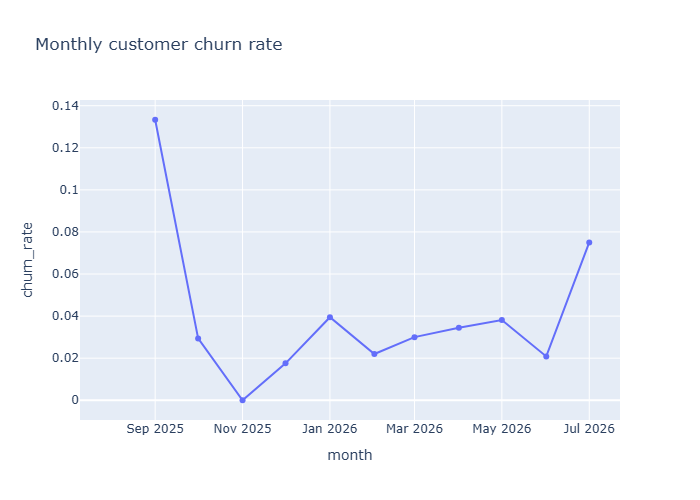

In [12]:
mrr["churn_rate"] = mrr.churned_customers / mrr.active_customers.shift(1)
px.line(mrr, x="month", y="churn_rate", markers=True, title="Monthly customer churn rate").show()

Churn rate = customers who left this month ÷ customers we had last month. Most months it sits around 2–4%,
which for a small SaaS is "fine, keep an eye on it". July's 7.5% is the card-failure spike again.


## 2. Who leaves, and why?

Two ways to look at churn: *which plan* people were on when they left, and *why* they left 
(did they cancel on purpose, or did their card quietly die?)

In [13]:
customers = query("select * from marts.dim_customer")

by_plan = pd.crosstab(customers.current_plan_key, customers.subscription_status)
by_plan["churn_pct"] = (by_plan.canceled / by_plan.sum(axis=1) * 100).round(1)
by_plan.sort_values("churn_pct", ascending=False)

subscription_status,active,canceled,churn_pct
current_plan_key,,,
basic_monthly,49,13,21.0
pro_monthly,34,8,19.0
basic_yearly,28,6,17.6
pro_yearly,19,4,17.4
enterprise_monthly,26,5,16.1
enterprise_yearly,8,0,0.0


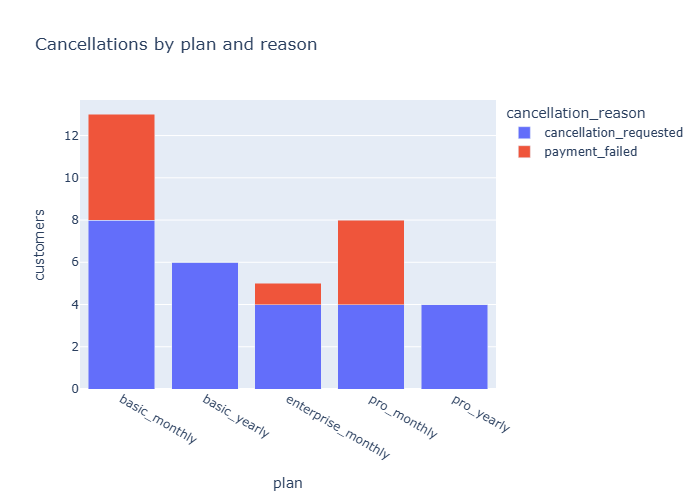

In [14]:
reasons = pd.crosstab(customers.current_plan_key, customers.cancellation_reason)
px.bar(
    reasons,
    barmode="stack",
    title="Cancellations by plan and reason",
    labels={"value": "customers", "current_plan_key": "plan"},
).show()

Basic monthly is the leakiest bucket (about one in five gone), Enterprise yearly hasn't lost anyone.
That's the usual pattern: the less someone pays, the less it hurts to leave.

The reason split is the interesting part. Roughly a quarter of all cancellations were never a decision,
`payment_failed` means the customer was happy, the card wasn't. Those are the cheapest customers to win back:
one "please update your card" email instead of a whole sales cycle.

## 3. Do customers stick around? Cohort retention

Take everyone who signed up in the same month (a *cohort*) and follow them: what share is still paying
one month later, two months later, and so on. Each row is a cohort, each column is "months since signup".
A healthy SaaS has rows that flatten out, people who survive the first few months tend to stay.

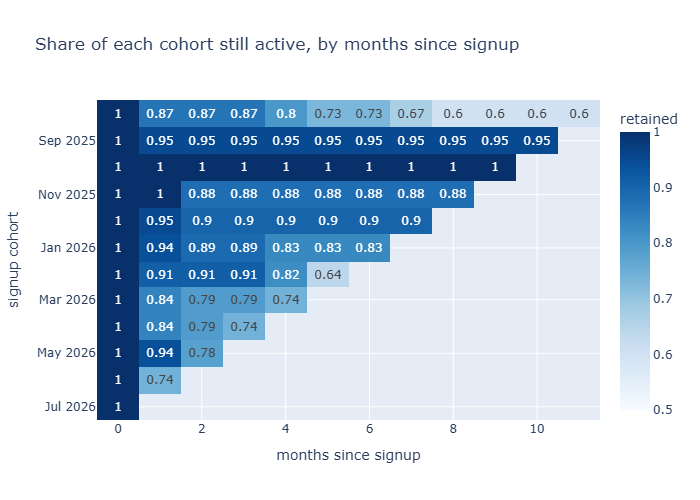

In [15]:
monthly = query("select customer_id, month, mrr from marts.mrr_customer_monthly")
monthly = monthly.merge(customers[["customer_id", "cohort_month"]], on="customer_id")

monthly["months_since_signup"] = (
    (monthly.month.dt.year - monthly.cohort_month.dt.year) * 12
    + (monthly.month.dt.month - monthly.cohort_month.dt.month)
)
monthly = monthly[monthly.months_since_signup >= 0]

retention = monthly.assign(active=monthly.mrr > 0).pivot_table(
    index="cohort_month", columns="months_since_signup", values="active", aggfunc="mean"
)
retention.index = retention.index.strftime("%Y-%m")

px.imshow(
    retention.round(2),
    text_auto=True,
    color_continuous_scale="Blues",
    zmin=0.5,
    zmax=1,
    aspect="auto",
    title="Share of each cohort still active, by months since signup",
    labels={"x": "months since signup", "y": "signup cohort", "color": "retained"},
).show()

The staircase shape is normal, later cohorts simply haven't had time to churn yet.
Reading the rows: most cohorts keep 85–95% of their customers after half a year, and the drop happens early.
The August 2025 cohort is the oldest and the leakiest (73% after five months); the ones that lost people
in July 2026 are, once again, the card-failure victims.

## 4. What is a customer worth? LTV by plan

Lifetime value = how much a customer pays us before leaving. Two ways to estimate it:

- **realized**: what customers on each plan have actually paid so far (honest, but young customers drag it down)
- **expected**: monthly price ÷ monthly churn rate, if 2% of a plan's customers leave each month,
  the average one stays 1 / 0.02 = 50 months

In [16]:
plans = query("select * from marts.dim_plan").set_index("plan_key")
events = query("select * from marts.fct_subscription_events")

customer_months = (
    query("select customer_id, month from marts.mrr_customer_monthly where mrr > 0")
    .merge(customers[["customer_id", "current_plan_key"]], on="customer_id")
    .groupby("current_plan_key").size()
    .rename("customer_months")
)
cancellations = events[events.event_type == "canceled"].groupby("plan_key").size().rename("cancellations")
ltv = plans[["plan_name", "billing_interval", "mrr_amount"]].join(customer_months).join(cancellations).fillna(0)
ltv["monthly_churn_pct"] = ltv.cancellations / ltv.customer_months * 100
ltv["expected_lifetime_months"] = 100 / ltv.monthly_churn_pct
ltv["expected_ltv"] = ltv.mrr_amount * ltv.expected_lifetime_months
ltv["realized_revenue_per_customer"] = customers.groupby("current_plan_key").lifetime_revenue.mean()
ltv.round(1).sort_values("expected_ltv", ascending=False)

,plan_name,billing_interval,mrr_amount,customer_months,cancellations,monthly_churn_pct,expected_lifetime_months,expected_ltv,realized_revenue_per_customer
plan_key,,,,,,,,,
enterprise_yearly,enterprise,year,82.5,50,0.0,0.0,inf,inf,927.5
enterprise_monthly,enterprise,month,99.0,181,5.0,2.8,36.2,3583.8,606.1
pro_yearly,pro,year,40.8,155,4.0,2.6,38.8,1582.2,550.0
pro_monthly,pro,month,49.0,206,8.0,3.9,25.8,1261.8,268.5
basic_monthly,basic,month,19.0,369,13.0,3.5,28.4,539.3,133.0
basic_yearly,basic,year,15.8,176,6.0,3.4,29.3,464.3,204.4


Enterprise monthly is the star: $99 a month and people stay ~3 years, so one customer is worth about $3,600.
Basic is cheap *and* leaves fastest, a double whammy: under $550 lifetime.
Enterprise yearly shows `inf` because nobody has cancelled yet, which is the nicest bug a business can have.

Realized revenue is much lower everywhere simply because most customers are only a few months old.

## 5. The money that never arrived: failed payments

A card fails, Stripe retries, sometimes it works, sometimes it doesn't. Three numbers matter:
how many charges bounced, how much is sitting unpaid right now, and how much MRR we lost when Stripe finally gave up.

In [17]:
invoices = query("select * from marts.fct_invoices")
charges = query("select status, count(*) as charges, sum(amount) as amount from staging.stg_charges group by 1")

unpaid = invoices[~invoices.is_paid]
lost_customers = customers[customers.cancellation_reason == "payment_failed"]
lost_mrr = events[(events.event_type == "canceled") & events.customer_id.isin(lost_customers.customer_id)].mrr_before.sum()

print(charges.to_string(index=False))
print(f"\nUnpaid invoices right now: {len(unpaid)} worth ${unpaid.amount_unpaid.sum():,.0f}")
print(f"Customers lost to card failures: {len(lost_customers)}, taking ${lost_mrr:,.0f} MRR with them (${lost_mrr * 12:,.0f} a year)")

unpaid.groupby("plan_name").amount_unpaid.sum().sort_values(ascending=False)

   status  charges  amount
succeeded      949 65329.0
   failed       70  2480.0

Unpaid invoices right now: 10 worth $390
Customers lost to card failures: 10, taking $390 MRR with them ($4,680 a year)


plan_name
pro           196.0
enterprise     99.0
basic          95.0
Name: amount_unpaid, dtype: float64

Seventy charges bounced, and every single failed customer went through the full retry cycle before Stripe cancelled them:
10 customers, $390 MRR — about **$4,700 a year** walking out over a card that expired.
For a business making $7,000 a month that's a bit more than half a month of revenue, lost to something a reminder email fixes.

## So, what do we tell leadership? 

1. **MRR is $7,050 and growing fast** — from $429 a year ago, almost entirely through new signups.
   Upgrades barely register: nobody moves up the plan ladder unless we push them.
2. **Churn is 2–4% a month, normal for our size** — except July, when it spiked to 7.5%.
3. **A quarter of all churn is accidental.** Ten customers didn't leave, their credit card did.
   That's ~$4,700 a year recoverable with dunning emails and a card-update prompt. Cheapest win on this list.
4. **Enterprise is where the value is** (~$3,600 lifetime per customer, near-zero churn on yearly);
   Basic monthly is the leakiest and least valuable plan. Yearly billing keeps people around on every tier.
5. **Next quarter's questions**: why doesn't anyone upgrade, and can we nudge Basic customers to yearly?

